In [1]:
import scanpy as sc
import pandas as pd
import os

# 디렉토리 설정
data_dir = "/home/Data_Drive_8TB/kykim/colon/Macrophage/"
adatas = []
# 파일 리스트와 sample 이름 정의
files = {
    "Mac_0hrs": "GSM5012287_Mac_0hrs_scRNAseq_counts.csv.gz",
    "M1_3hrs": "GSM5012288_M1_3hrs_scRNAseq_counts.csv.gz",
    "M1_6hrs": "GSM5012289_M1_6hrs_scRNAseq_counts.csv.gz",
    "M1_12hrs": "GSM5012290_M1_12hrs_scRNAseq_counts.csv.gz",
    "M1_24hrs": "GSM5012291_M1_24hrs_scRNAseq_counts.csv.gz",
    "M2_3hrs": "GSM5012292_M2_3hrs_scRNAseq_counts.csv.gz",
    "M2_6hrs": "GSM5012293_M2_6hrs_scRNAseq_counts.csv.gz",
    "M2_12hrs": "GSM5012294_M2_12hrs_scRNAseq_counts.csv.gz",
    "M2_24hrs": "GSM5012295_M2_24hrs_scRNAseq_counts.csv.gz"}

for sample_name, filename in files.items():
    file_path = os.path.join(data_dir, filename)
    
    # CSV 파일을 pandas DataFrame으로 불러오기 (index_col=0 은 gene명 기준)
    df = pd.read_csv(file_path, index_col=0)
    
    # DataFrame을 AnnData로 변환
    adata = sc.AnnData(df.transpose())  # cells x genes 형태로 transpose 필요
    adata.obs['sample'] = sample_name
    
    # Cell 이름 prefix로 구분 가능하도록 바꾸기
    adata.obs_names = [f"{sample_name}_{cell}" for cell in adata.obs_names]
    
    adatas.append(adata)

# 병합
adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감


/tmp/ipykernel_368257/1876977393.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감


In [2]:
def assign_cell_type(sample):
    if sample.startswith("Mac_"):
        return "M0"
    elif sample.startswith("M1_"):
        return "M1"
    elif sample.startswith("M2_"):
        return "M2"
    else:
        return "Unknown"

adata.obs['cell_type'] = adata.obs['sample'].apply(assign_cell_type)
print(adata.obs['cell_type'].value_counts())


cell_type
M0    4145
M1    1904
M2    1527
Name: count, dtype: int64


In [ ]:
import scanpy as sc

# h5ad 파일 경로
file_path = '/home/Data_Drive_8TB/kykim/GC/Macrophage.h5ad'

# h5ad 파일 읽기
trainadata = sc.read_h5ad(file_path)


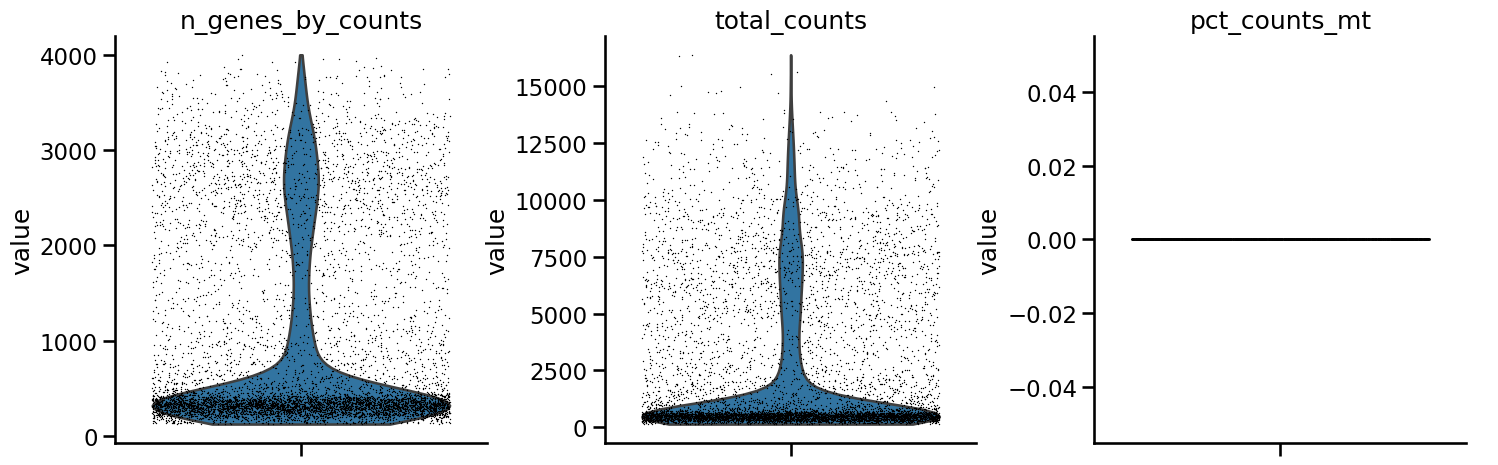

(7576, 35689)


In [3]:
import scanpy as sc
from scib.integration import combat

import scanpy as sc
adata.layers["counts"] = adata.X.copy()
raw_var_names = adata.var_names.copy()

rawadata = adata.copy()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


print(adata.X.shape)

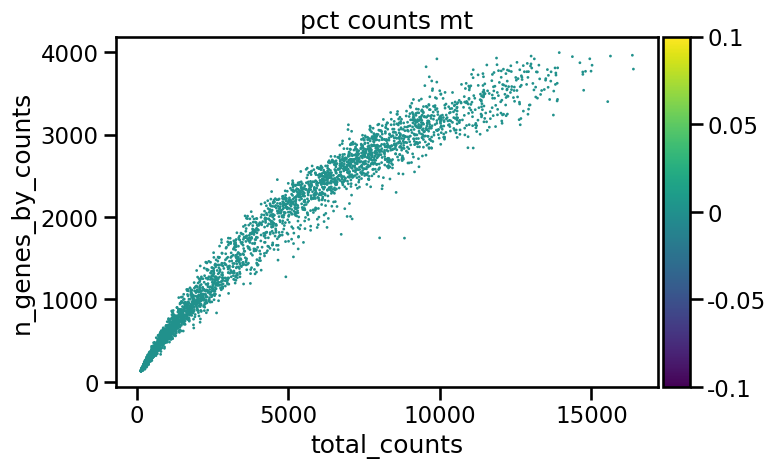

(7576, 14533)


In [4]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(adata.X.shape)

In [5]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=5000,batch_key="sample")
print(adata.X.shape)

(7576, 14533)


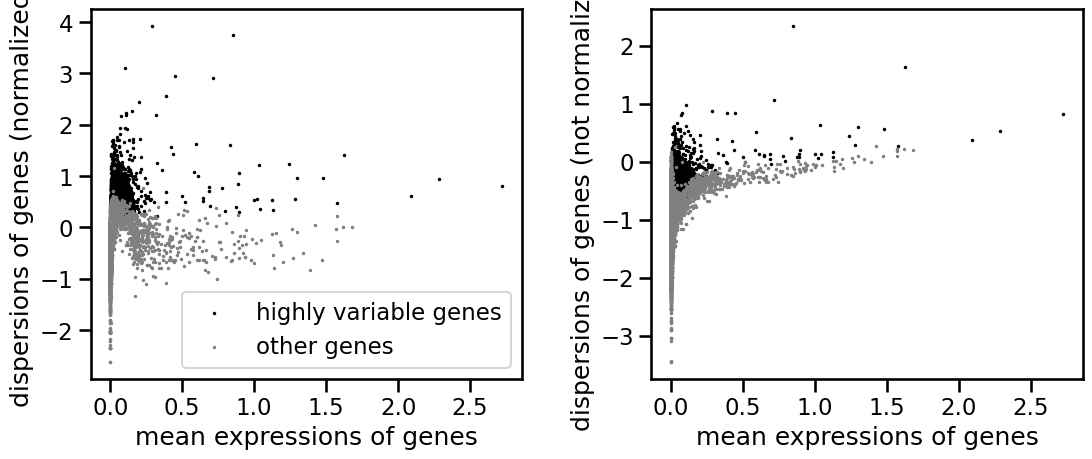

In [6]:
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']]

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


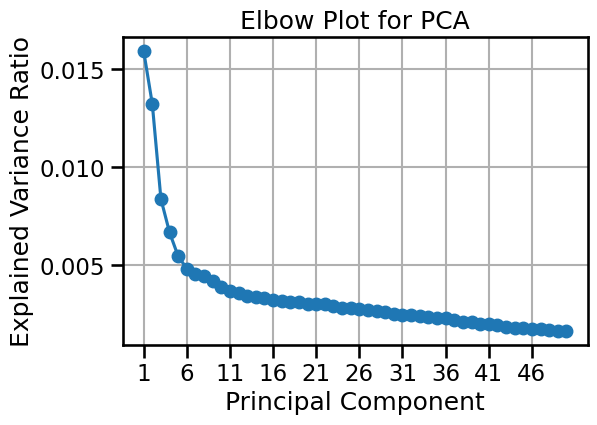

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

sc.tl.pca(adata, n_comps=46)

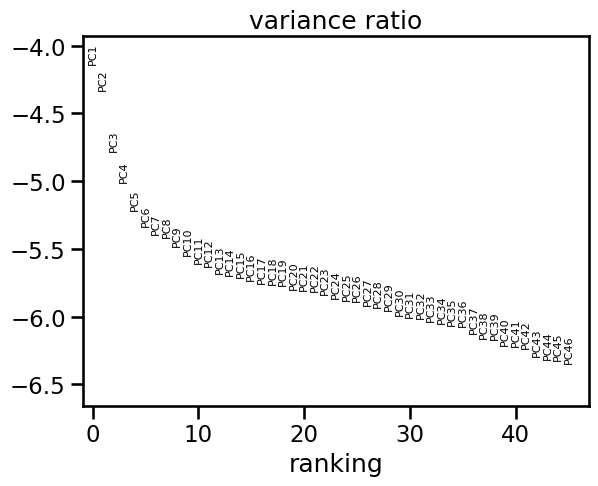

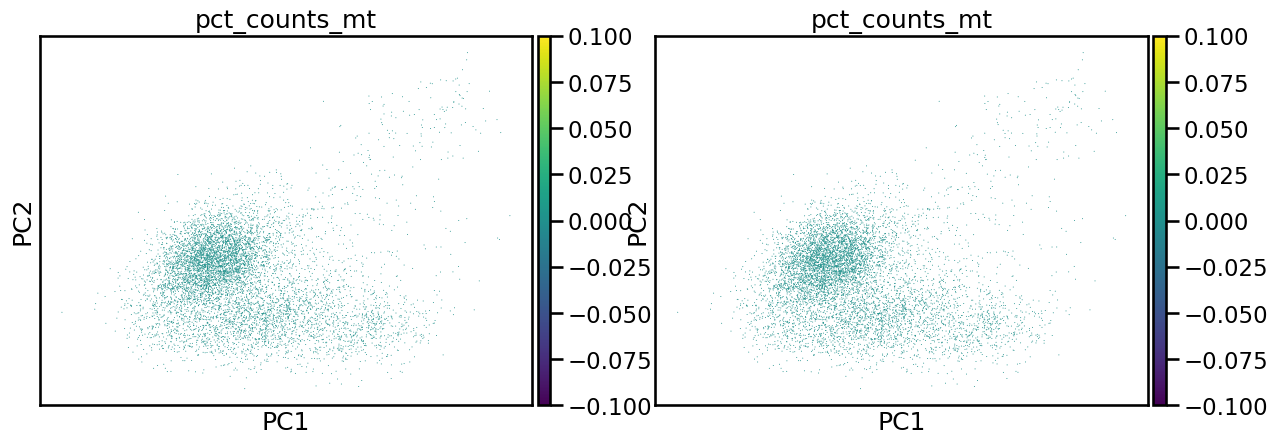

In [8]:
sc.pl.pca_variance_ratio(adata, n_pcs=46, log=True)
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    ncols=2,
    size=2,
)

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


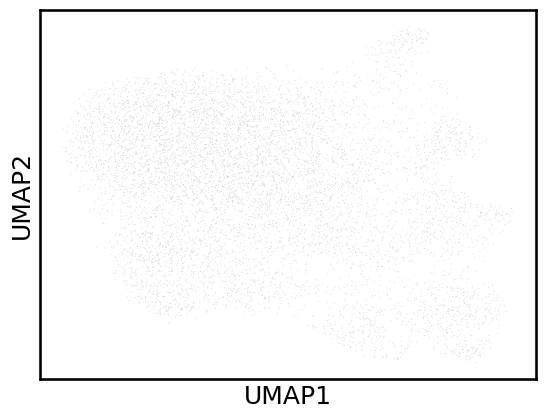

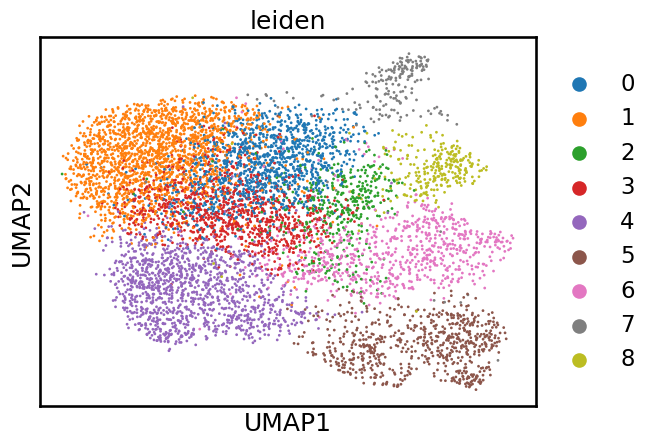

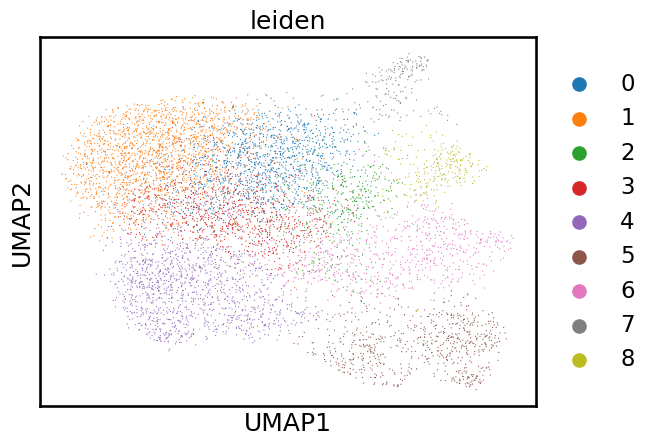

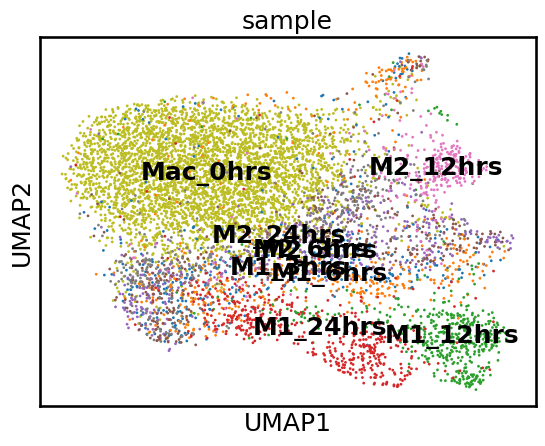

In [9]:
import bbknn 
import scanpy as sc
import scanpy.external as sce

sce.pp.bbknn(adata, batch_key='cell_type')
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    size=2,
)
sc.pl.umap(adata, color=["leiden"])
sc.pl.umap(
    adata,
    color=["leiden"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)
sc.pl.umap(
    adata,
    color=['sample'],
    legend_loc="on data",
)

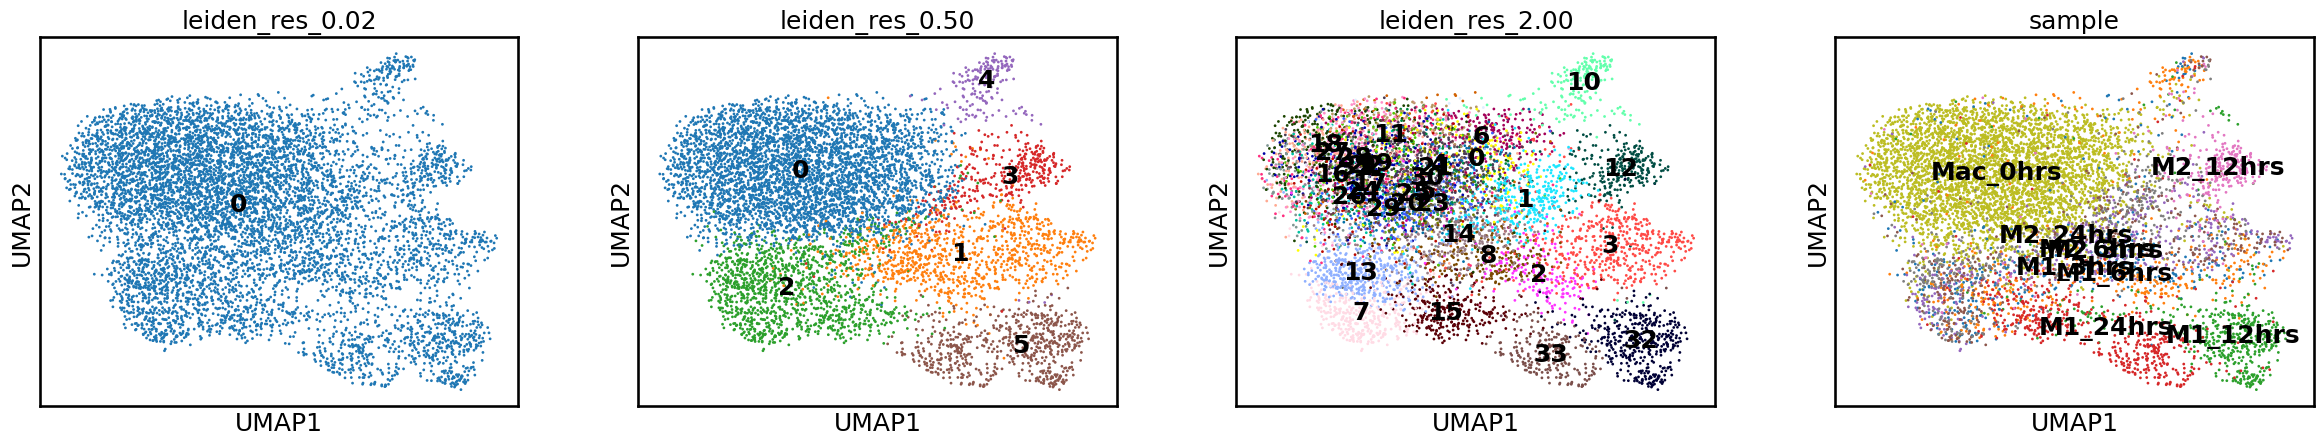

In [10]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00",'sample'],
    legend_loc="on data",
)

In [11]:
# import matplotlib.pyplot as plt

# plt.rcParams.update({
#     'font.size': 8,           # 기본 폰트 크기
#     'axes.titlesize': 10,     # 제목
#     'axes.labelsize': 8,      # 축 이름
#     'xtick.labelsize': 6,     # x축 눈금
#     'ytick.labelsize': 6,     # y축 눈금
#     'legend.fontsize': 7      # 범례
# })

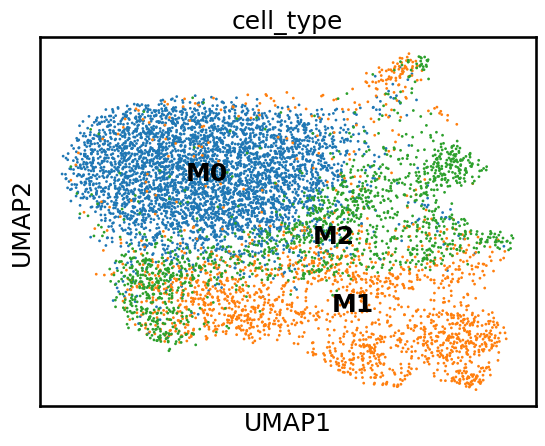

In [12]:
sc.pl.umap(
    adata,
    color=['cell_type'],
    legend_loc="on data",
)

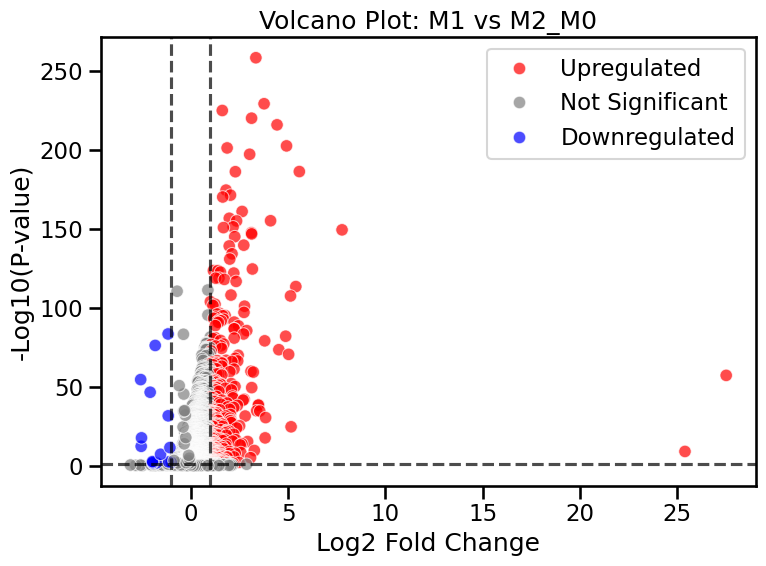

['CXCL10', 'CCL8', 'TRIM22', 'SAMD9L', 'GBP3', 'OAS1', 'TNFSF13B', 'TAGAP', 'PARP9', 'SOCS1', 'IFI35', 'TNFAIP2', 'DTX3L', 'MLKL', 'FAS', 'IRF9', 'LAP3', 'IL1B', 'RHBDF2', 'IRF7']


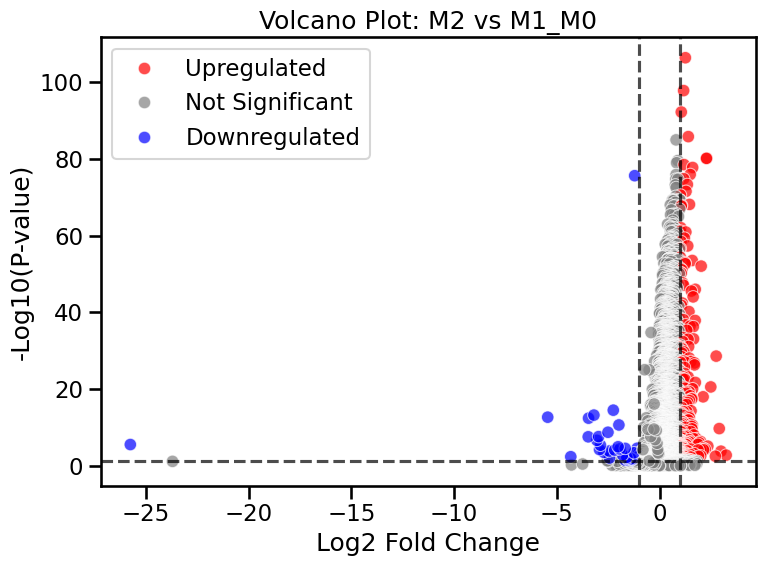

['TOGARAM2', 'SIGLEC10', 'CD300LB', 'SPP1', 'SLIT3', 'OLR1', 'SMOX', 'RGS16', 'NET1', 'PGBD5', 'FBP1', 'FGR', 'ATP2B2', 'SMAD6', 'CSF1R', 'ANKS6', 'GAL', 'ZCCHC24', 'TM4SF19', 'MFGE8']


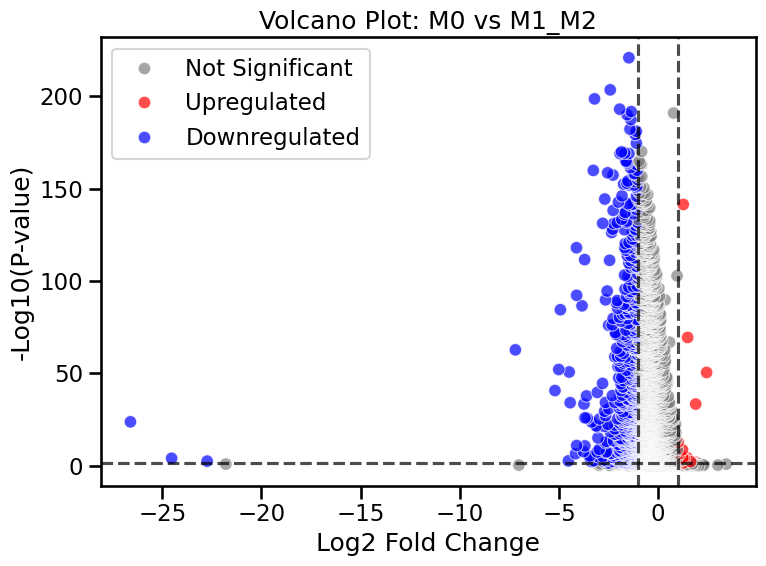

['TEX30', 'SLC5A3', 'MRPS6', 'CYTIP', 'SUCNR1', 'RPS27P29', 'RPSAP19', 'RPL7P32', 'STMN1', 'HERC2P2', 'TIMP1', 'TXNIP', 'ERCC5', 'ARHGAP9', 'LONRF2', 'MPZL3', 'RPS27AP11', 'PLTP', 'MID1IP1']


In [13]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 특정 그룹을 묶어서 새로운 참조 그룹 생성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# 🔹 그룹 병합 함수
def merge_groups(adata, groupby, group1, ref_groups):
    adata = adata.copy()
    ref_name = "_".join(ref_groups)  # 예: "M2_M3"
    adata.obs[groupby] = adata.obs[groupby].astype(str)
    
    # ref_groups를 하나의 그룹으로 묶기
    adata.obs[groupby] = adata.obs[groupby].replace(ref_groups, ref_name)
    
    return adata, ref_name

# 🔹 볼케이노 플롯 함수
def plot_volcano(deg_results, group1, reference):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=deg_results, x="logFC", y="neg_log_pval", hue="significance",
                    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "gray"},
                    alpha=0.7)

    plt.axvline(x=1, linestyle='--', color='black', alpha=0.7)
    plt.axvline(x=-1, linestyle='--', color='black', alpha=0.7)
    plt.axhline(y=-np.log10(0.05), linestyle='--', color='black', alpha=0.7)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10(P-value)")
    plt.title(f"Volcano Plot: {group1} vs {reference}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 🔹 DEG 분석 함수 + Upregulated 유전자 반환 (log2FC ≤ 5)
def run_deg_analysis(adata, groupby, group1, ref_groups, logfc_threshold=1, pval_threshold=0.05, top_n=20):
    # 그룹 병합
    adata, reference = merge_groups(adata, groupby, group1, ref_groups)
    
    # DEG 분석 (Wilcoxon rank-sum test)
    sc.tl.rank_genes_groups(adata, groupby=groupby, groups=[group1], reference=reference, method='wilcoxon')

    # 결과 저장
    result = adata.uns['rank_genes_groups']
    deg_results = pd.DataFrame({
        "gene": result['names'][group1],
        "logFC": result['logfoldchanges'][group1],
        "pval": result['pvals'][group1]
    })

    # 0을 작은 값으로 대체하여 log 변환 가능하게 처리
    deg_results["pval"] = deg_results["pval"].replace(0, 1e-300)
    deg_results["neg_log_pval"] = -np.log10(deg_results["pval"])

    # DEG 필터링 및 라벨링
    deg_results["significance"] = "Not Significant"
    deg_results.loc[(deg_results["logFC"] > logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Upregulated"
    deg_results.loc[(deg_results["logFC"] < -logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Downregulated"

    # 볼케이노 플롯
    plot_volcano(deg_results, group1, reference)

    # 🔹 log2FC ≤ 5 조건 추가 후 상위 20개 Upregulated 유전자 추출
    upregulated_genes = deg_results[
        (deg_results["logFC"] > logfc_threshold) & 
        (deg_results["logFC"] <= 10000) & 
        (deg_results["pval"] < pval_threshold)
    ].sort_values("logFC", ascending=False)["gene"].head(top_n).tolist()

    return upregulated_genes


upregulated_gene_list = run_deg_analysis(adata, groupby="cell_type", group1="M1", ref_groups=["M2", "M0"])
print(upregulated_gene_list)
upregulated_gene_list = run_deg_analysis(adata, groupby="cell_type", group1="M2", ref_groups=["M1", "M0"])
print(upregulated_gene_list)
upregulated_gene_list = run_deg_analysis(adata, groupby="cell_type", group1="M0", ref_groups=["M1", "M2"])
print(upregulated_gene_list)

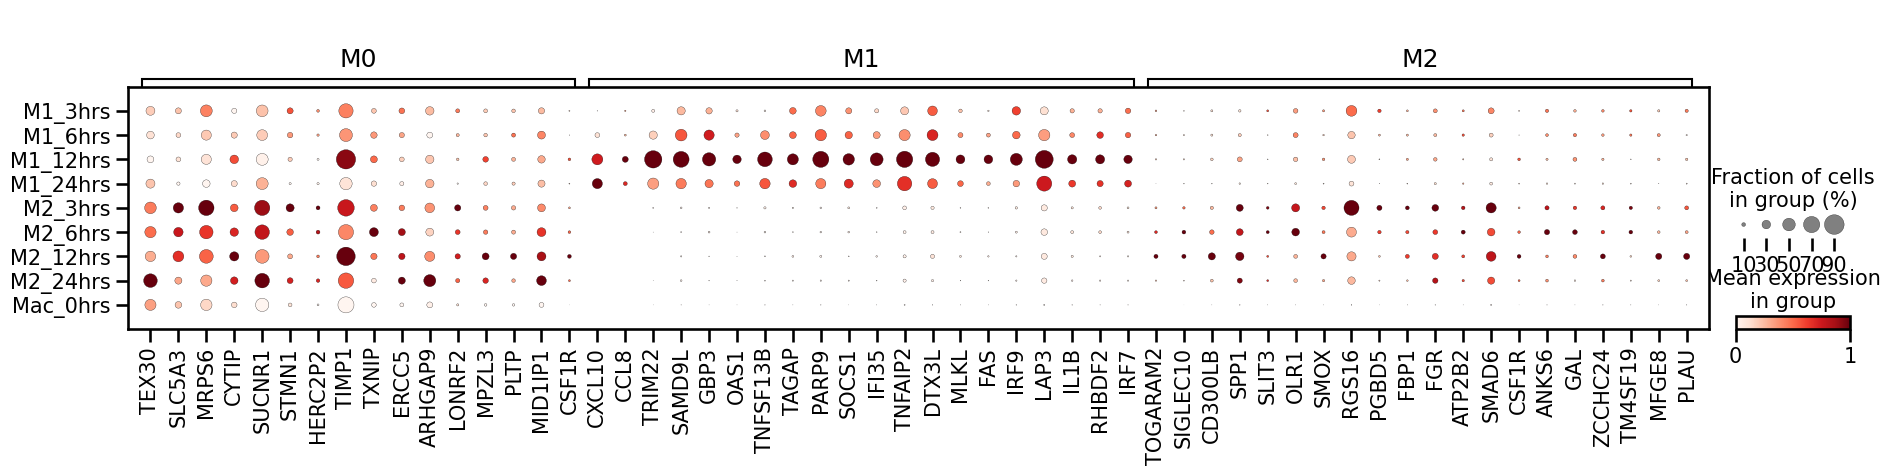

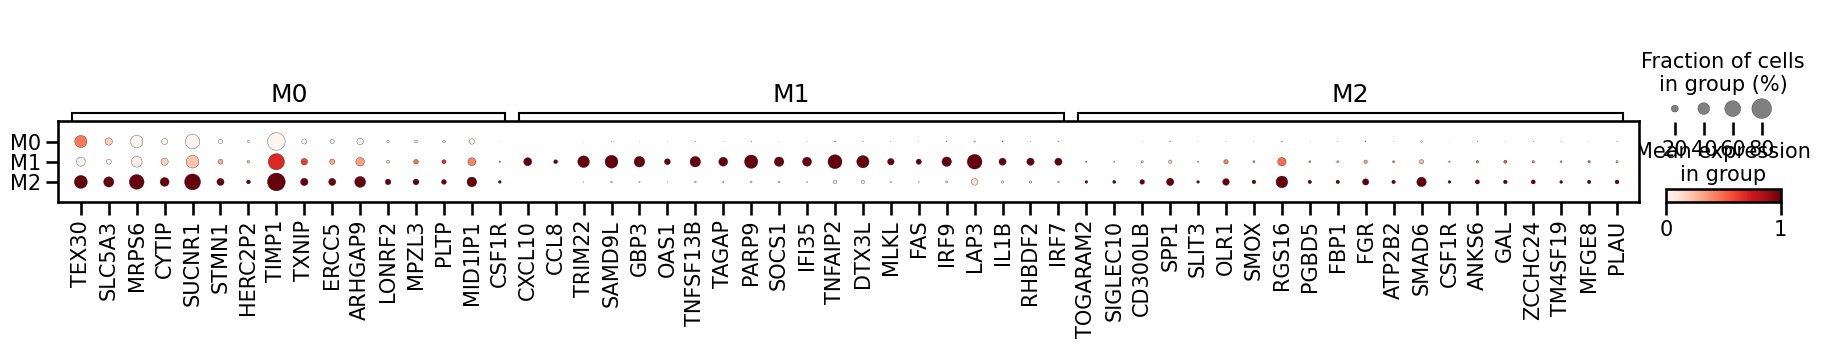

In [112]:
marker_genes = {
    "M0": ['TEX30', 'SLC5A3', 'MRPS6', 'CYTIP', 'SUCNR1', 'STMN1', 'HERC2P2', 'TIMP1', 'TXNIP', 'ERCC5', 'ARHGAP9', 'LONRF2', 'MPZL3', 'PLTP', 'MID1IP1','CSF1R'],
    "M1": ['CXCL10', 'CCL8', 'TRIM22', 'SAMD9L', 'GBP3', 'OAS1', 'TNFSF13B', 'TAGAP', 'PARP9', 'SOCS1', 'IFI35', 'TNFAIP2', 'DTX3L', 'MLKL', 'FAS', 'IRF9', 'LAP3', 'IL1B', 'RHBDF2', 'IRF7'],
    "M2": ['TOGARAM2', 'SIGLEC10', 'CD300LB', 'SPP1', 'SLIT3', 'OLR1', 'SMOX', 'RGS16', 'PGBD5', 'FBP1', 'FGR', 'ATP2B2', 'SMAD6', 'CSF1R', 'ANKS6', 'GAL', 'ZCCHC24', 'TM4SF19', 'MFGE8', 'PLAU']
}
marker_genes = {cat: [gene for gene in genes if gene in adata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(adata, marker_genes, groupby="sample", standard_scale="var")
sc.pl.dotplot(adata, marker_genes, groupby="cell_type", standard_scale="var")

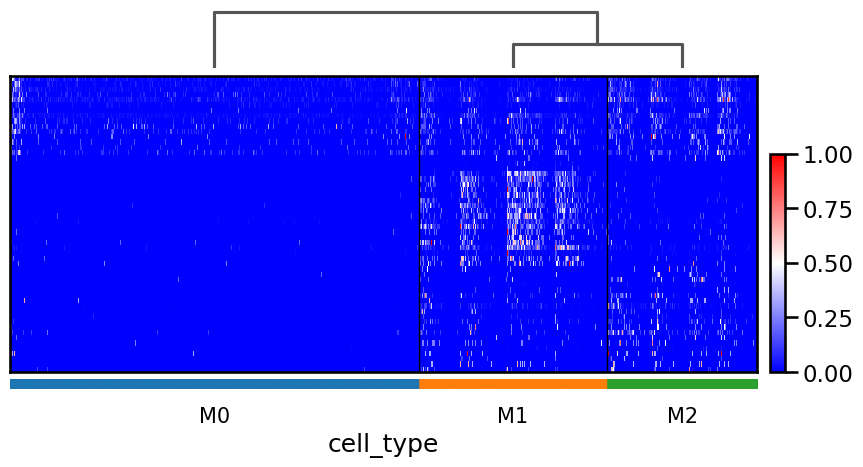

In [115]:
import scanpy as sc

# marker genes를 평탄화해서 하나의 리스트로 만들기
marker_gene_list = marker_genes["M0"] + marker_genes["M1"] + marker_genes["M2"]

# 히트맵 그리기
sc.pl.heatmap(
    adata,
    var_names=marker_gene_list,
    groupby='cell_type',       # cell type 별 평균 발현 보여줌
    use_raw=False,             # 필요한 경우 True로 (adata.raw에 데이터가 있을 경우)
    cmap='bwr',                # blue-white-red 색상
    swap_axes=True,            # 유전자가 x축
    dendrogram=True,           # 클러스터링
    standard_scale='var'       # 유전자별 z-score 정규화 (선택)
)


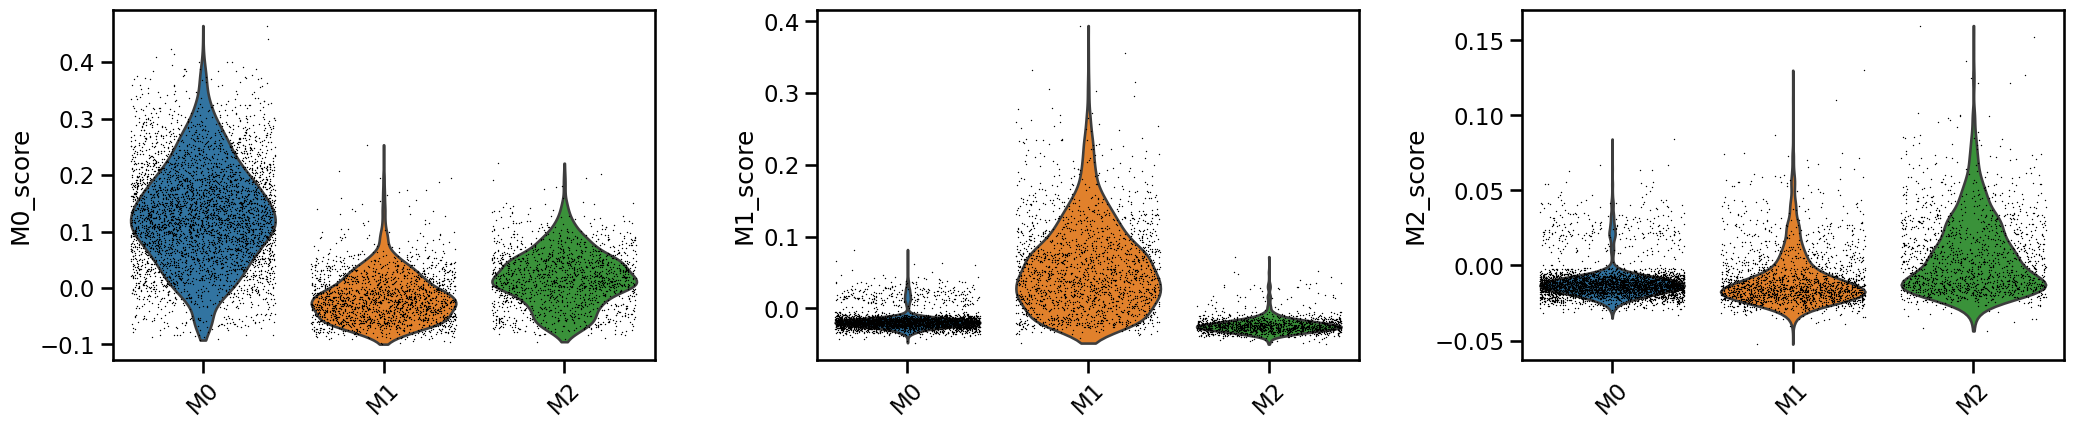

In [17]:
# 각 마커에 대해 score 계산
for label, genes in marker_genes.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(adata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='cell_type', jitter=0.4, rotation=45)


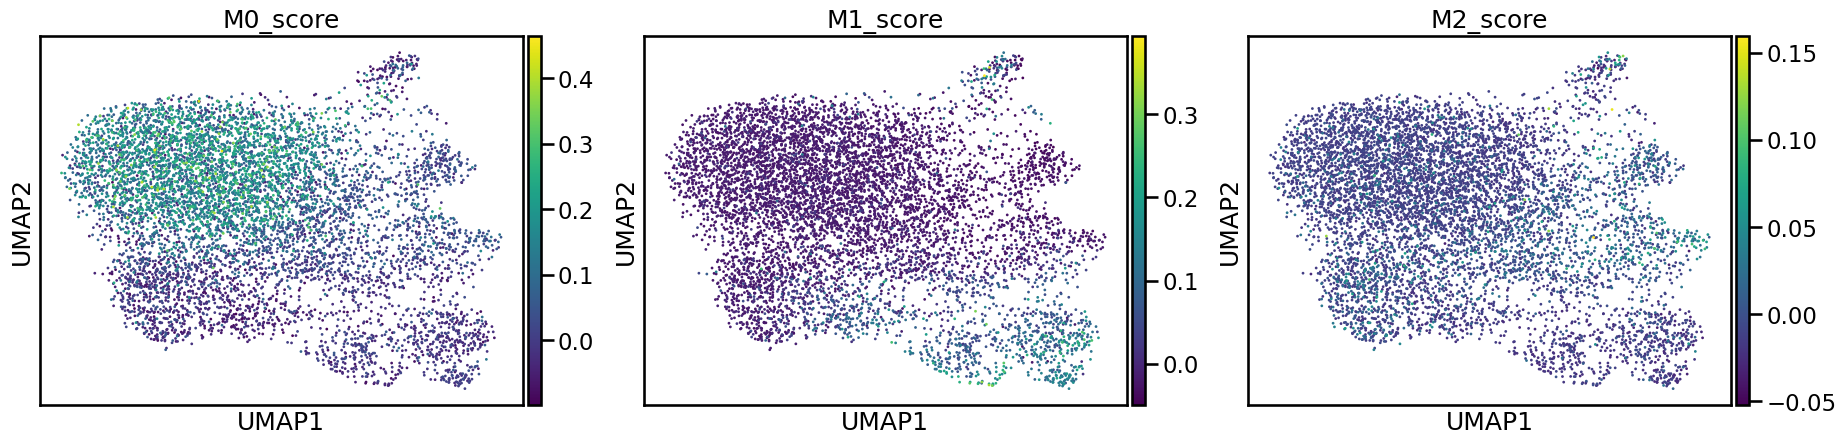

In [18]:
sc.pl.umap(adata, color=['M0_score', 'M1_score', 'M2_score'])


In [111]:
adata.X = adata.layers["counts"]

In [105]:
import pandas as pd

# 유전자 목록 정의

gene_sets = {
    "M0": ['TEX30', 'EGR1', 'SLC5A3', 'MRPS6', 'EGR3', 'FILIP1L', 'ADARB1', 'CYTIP', 'IL1RN', 'DUSP2', 'STMN1','CD14','CD68','CSF1R'],
    "M1": ['CXCL10', 'CCL8', 'TRIM22', 'SAMD9L', 'GBP3', 'OAS1', 'TNFSF13B', 'TAGAP', 'PARP9', 'SOCS1', 'IFI35', 'TNFAIP2', 'DTX3L', 'MLKL', 'FAS', 'IRF9', 'LAP3', 'IL1B', 'RHBDF2', 'IRF7'],
    "M2": ['TOGARAM2', 'SIGLEC10', 'CD300LB', 'SPP1', 'SLIT3', 'OLR1', 'SMOX', 'RGS16', 'PGBD5', 'FBP1', 'FGR', 'ATP2B2', 'SMAD6', 'CSF1R', 'ANKS6', 'GAL', 'ZCCHC24', 'TM4SF19', 'MFGE8', 'PLAU']
}

# 모든 유전자 목록 합치기
all_genes = gene_sets["M0"] + gene_sets["M1"] + gene_sets["M2"]

# 실제 adata.var_names에 존재하는 유전자만 필터링
existing_genes = [gene for gene in all_genes if gene in adata.var_names]

# 유전자 발현값 추출
gene_df = adata[:, existing_genes].to_df()

# cell_type 열 추가
gene_df['cell_type'] = adata.obs['cell_type'].values

# 결과 확인 (옵션)
gene_df


gene_name,TEX30,EGR1,SLC5A3,MRPS6,EGR3,FILIP1L,ADARB1,CYTIP,IL1RN,DUSP2,...,ATP2B2,SMAD6,CSF1R,ANKS6,GAL,ZCCHC24,TM4SF19,MFGE8,PLAU,cell_type
Mac_0hrs_BM0_cell10002-0,9.0,9.0,2.00,4.00,0.0,2.0,3.0,2.0,0.0,0.0,...,0.0,4.0,0.0,1.0,0.0,0.0,0.00,0.0,0.0,M0
Mac_0hrs_BM0_cell10004-0,2.0,0.0,11.01,14.99,0.0,0.0,0.0,5.0,4.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,5.35,1.0,0.0,M0
Mac_0hrs_BM0_cell10006-0,7.0,1.0,1.00,1.00,2.0,2.0,1.0,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.0,0.0,M0
Mac_0hrs_BM0_cell10007-0,7.0,2.0,9.00,7.00,1.0,0.0,1.0,5.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.0,0.0,M0
Mac_0hrs_BM0_cell10008-0,5.0,7.0,5.00,4.00,3.0,5.0,0.0,7.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,M0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M2_24hrs_LM2.24hrs_celll489-8,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.00,0.0,0.0,M2
M2_24hrs_LM2.24hrs_celll493-8,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,M2
M2_24hrs_LM2.24hrs_celll494-8,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,M2
M2_24hrs_LM2.24hrs_celll495-8,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,M2


📊 Confusion Matrix:
[[782  14  33]
 [ 45 319  17]
 [ 99  11 196]]

📝 Classification Report:
              precision    recall  f1-score   support

          M0       0.84      0.94      0.89       829
          M1       0.93      0.84      0.88       381
          M2       0.80      0.64      0.71       306

    accuracy                           0.86      1516
   macro avg       0.86      0.81      0.83      1516
weighted avg       0.86      0.86      0.85      1516



/tmp/ipykernel_368257/2111798204.py:48: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


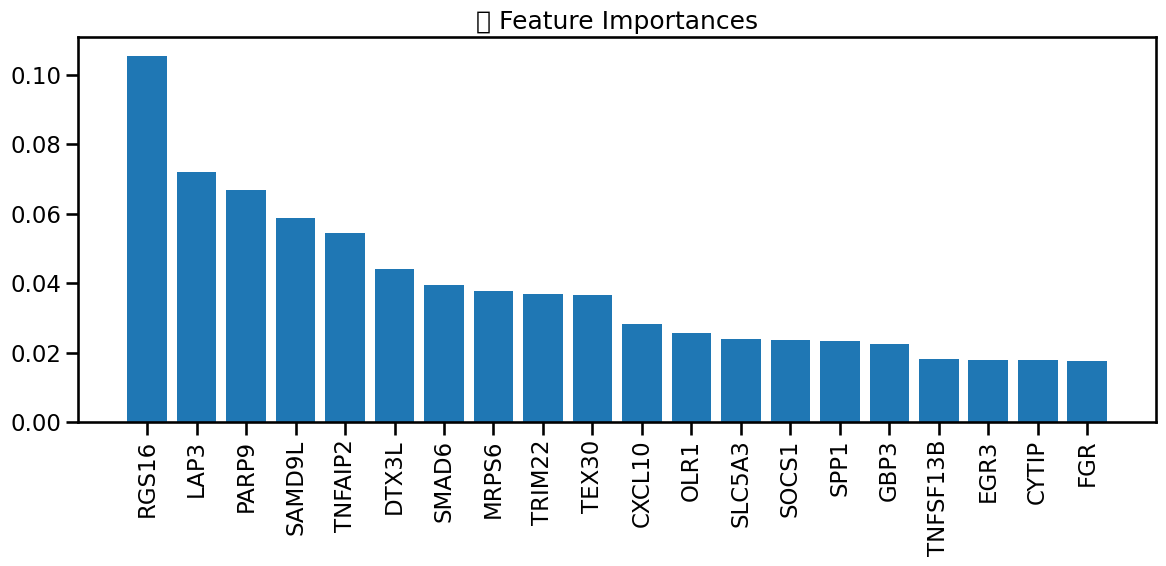


✅ Cross-Validation Accuracy Scores: [0.81332454 0.86930693 0.84620462 0.87656766 0.79735974]
📌 Mean CV Accuracy: 0.8406


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature와 Label 분리
X = gene_df.drop(columns='cell_type')
y = gene_df['cell_type']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_scaled = X_train
# X_test_scaled = X_test

# 4. 기본 RandomForest 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 5. 예측 및 평가
y_pred = rf.predict(X_test_scaled)

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Feature Importance 시각화
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]

plt.figure(figsize=(12, 6))
plt.title("📈 Feature Importances")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), features[:20], rotation=90)
plt.tight_layout()
plt.show()

# 7. Cross-validation score (기본 모델 성능 확인)
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\n✅ Cross-Validation Accuracy Scores: {cv_scores}")
print(f"📌 Mean CV Accuracy: {cv_scores.mean():.4f}")

In [56]:
# 8. GridSearchCV로 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n🔍 Best Parameters: {grid_search.best_params_}")
print(f"🎯 Best CV Score: {grid_search.best_score_:.4f}")

# 최적 모델로 테스트셋 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\n🧪 Test Set Evaluation (Best Model):")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 24 candidates, totalling 72 fits

🔍 Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
🎯 Best CV Score: 0.8568

🧪 Test Set Evaluation (Best Model):
[[793  11  25]
 [ 43 319  19]
 [ 98  13 195]]
              precision    recall  f1-score   support

          M0       0.85      0.96      0.90       829
          M1       0.93      0.84      0.88       381
          M2       0.82      0.64      0.72       306

    accuracy                           0.86      1516
   macro avg       0.86      0.81      0.83      1516
weighted avg       0.86      0.86      0.86      1516



In [72]:
import scanpy as sc

# h5ad 파일 경로
file_path = '/home/Data_Drive_8TB/kykim/GC/Macrophage.h5ad'

# h5ad 파일 읽기
trainadata = sc.read_h5ad(file_path)


In [73]:
all_genes = gene_sets["M0"] + gene_sets["M1"] + gene_sets["M2"]
existing_genes = [gene for gene in all_genes if gene in trainadata.var_names]

# 3. 유전자 발현 데이터프레임 추출 (trainadata에서 test set용으로)
test_df = trainadata[:, existing_genes].to_df()

# caler = StandardScaler()
# test_scaled = caler.fit_transform(test_df)

# X_test_scaled = test_df
test_scaled = scaler.transform(test_df)

# 5. 필요하다면 DataFrame 형태로 변환
test_scaled_df = pd.DataFrame(test_scaled, columns=existing_genes, index=test_df.index)

test_scaled_df

,TEX30,EGR1,SLC5A3,MRPS6,EGR3,FILIP1L,ADARB1,CYTIP,IL1RN,DUSP2,...,FGR,ATP2B2,SMAD6,CSF1R,ANKS6,GAL,ZCCHC24,TM4SF19,MFGE8,PLAU
AAAGATGTCAATACCG_8,-0.534471,74.156453,0.379643,0.520329,3.534995,9.479470,-0.258284,0.832947,2.399639,20.053000,...,1.849638,-0.144,-0.271273,5.115129,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,14.861382
AATCCAGCACCGATAT_8,-0.534471,-0.330335,-0.331532,0.009854,-0.334133,4.610168,-0.258284,0.832947,-0.234986,21.614066,...,-0.195765,-0.144,-0.271273,78.544497,-0.181353,-0.10034,-0.181477,-0.116992,4.332070,-0.144029
ACCAGTAGTAAGTGGC_8,-0.534471,0.999786,1.801995,-0.500621,-0.334133,4.610168,-0.258284,-0.381893,-0.234986,20.053000,...,1.849638,-0.144,-0.271273,-0.129826,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,17.362284
ACGCAGCGTATAATGG_8,-0.534471,34.252816,3.935522,-0.500621,-0.334133,7.044819,-0.258284,-0.381893,-0.234986,7.564472,...,-0.195765,-0.144,-0.271273,26.094948,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,-0.144029
ATCATGGCAGTCAGAG_8,-0.534471,2.329907,-0.331532,1.030804,0.955577,-0.259134,-0.258284,4.477465,-0.234986,37.224726,...,1.849638,-0.144,-0.271273,10.360084,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,-0.144029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGTCAGCACAAAT.1_40,0.969543,0.999786,-0.331532,-0.500621,-0.334133,-0.259134,-0.258284,-0.381893,55.092130,-0.240858,...,-0.195765,-0.144,-0.271273,-0.129826,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,-0.144029
TTTAGTCGTCTGGTTA.1_40,-0.534471,27.602210,0.379643,0.009854,2.245286,-0.259134,-0.258284,0.832947,1.082326,-0.240858,...,-0.195765,-0.144,-0.271273,5.115129,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,4.857775
TTTCACATCATTGCGA.1_40,-0.534471,2.329907,-0.331532,-0.500621,-0.334133,-0.259134,-0.258284,-0.381893,8.986200,7.564472,...,-0.195765,-0.144,-0.271273,5.115129,-0.181353,-0.10034,-0.181477,-0.116992,-0.160118,-0.144029
TTTGGTTGTGAGCTCC.1_40,-0.534471,-0.330335,0.379643,-0.500621,3.534995,-0.259134,-0.258284,-0.381893,2.399639,6.003406,...,1.849638,-0.144,-0.271273,-0.129826,-0.181353,-0.10034,3.926519,-0.116992,-0.160118,-0.144029


In [74]:
train_features = X_train.columns
test_features = test_scaled_df.columns

missing_features = set(train_features) - set(test_features)
print("❗ 누락된 feature 목록 (총 {}개):".format(len(missing_features)))
print(sorted(missing_features))


❗ 누락된 feature 목록 (총 0개):
[]


In [75]:
# 예측 확률 추출
test_proba = rf.predict_proba(test_scaled_df.values)
test_pred = rf.predict(test_scaled_df.values)
# 클래스 라벨
class_labels = rf.classes_

# 확률 DataFrame 생성
proba_df = pd.DataFrame(test_proba, columns=[f'proba_{cls}' for cls in class_labels], index=test_scaled_df.index)

# cell_id와 predicted_cell_type 포함한 기본 DataFrame
test_pred_df = pd.DataFrame({
    'cell_id': test_scaled_df.index,
    'predicted_cell_type': test_pred
})

# 확률 정보 붙이기
test_pred_df = pd.concat([test_pred_df, proba_df.reset_index(drop=True)], axis=1)

# 결과 확인
print(test_pred_df.head())


              cell_id predicted_cell_type  proba_M0  proba_M1  proba_M2
0  AAAGATGTCAATACCG_8                  M1      0.15    0.5300    0.3200
1  AATCCAGCACCGATAT_8                  M1      0.13    0.6075    0.2625
2  ACCAGTAGTAAGTGGC_8                  M2      0.34    0.2900    0.3700
3  ACGCAGCGTATAATGG_8                  M1      0.24    0.5300    0.2300
4  ATCATGGCAGTCAGAG_8                  M1      0.07    0.6400    0.2900


In [76]:
test_pred_df['predicted_cell_type'].value_counts()

predicted_cell_type
M1    6755
M2    2898
M0    1097
Name: count, dtype: int64

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


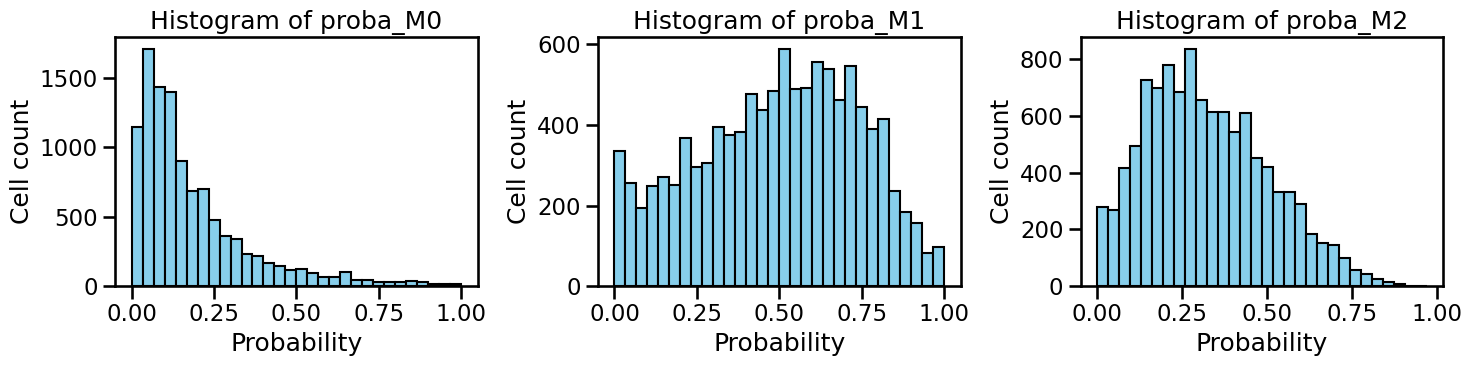

In [77]:
import matplotlib.pyplot as plt
proba_cols = ['proba_M0', 'proba_M1', 'proba_M2']

proba = rf.predict_proba(test_scaled_df)
trainadata.obs['predict'] = test_pred
# 다중 클래스라면, 결과가 list of arrays일 수 있음 (클래스별)
# 각 클래스 확률을 obs에 저장
for i, class_name in enumerate(['proba_M0', 'proba_M1', 'proba_M2']):
    trainadata.obs[class_name] = proba[:, i]

# 플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(proba_cols):
    axes[i].hist(trainadata.obs[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('Probability')
    axes[i].set_ylabel('Cell count')




plt.tight_layout()
plt.show()


In [78]:
vc = trainadata.obs.groupby('status')['predict'].value_counts()
print(vc)

status  predict
Normal  M1          668
        M2          170
        M0          118
Tumor   M1         6087
        M2         2728
        M0          979
Name: count, dtype: int64


/tmp/ipykernel_368257/3279289992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vc = trainadata.obs.groupby('status')['predict'].value_counts()


In [79]:
proba_cols = ['proba_M0', 'proba_M1', 'proba_M2']
trainadata.obs['max_prob'] = trainadata.obs[proba_cols].max(axis=1)
trainadata.obs

,sample,status,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,...,leiden_res_0.75,leiden_res_1.00,leiden_res_1.25,leiden_res_0.07,over_clustering,predict,proba_M0,proba_M1,proba_M2,max_prob
AAAGATGTCAATACCG_8,GSM5573466_sample1,Normal,3016,11630,32.957868,43.465176,55.279450,70.232158,1150,9.888220,...,0,0,0,0,93,M1,0.150000,0.530000,0.320000,0.530000
AATCCAGCACCGATAT_8,GSM5573466_sample1,Normal,3197,13343,41.707262,49.441655,57.663194,69.699468,2304,17.267481,...,0,0,0,0,20,M1,0.130000,0.607500,0.262500,0.607500
ACCAGTAGTAAGTGGC_8,GSM5573466_sample1,Normal,1356,2874,30.619346,40.883786,52.609603,70.215727,114,3.966597,...,0,0,0,0,88,M2,0.340000,0.290000,0.370000,0.370000
ACGCAGCGTATAATGG_8,GSM5573466_sample1,Normal,2175,7067,37.031272,48.139239,58.737795,72.406962,145,2.051790,...,0,0,0,0,88,M1,0.240000,0.530000,0.230000,0.530000
ATCATGGCAGTCAGAG_8,GSM5573466_sample1,Normal,3200,13640,29.501466,41.979472,55.879765,70.425220,1125,8.247801,...,4,2,2,2,77,M1,0.070000,0.640000,0.290000,0.640000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGTCAGCACAAAT.1_40,GSM5573505_sample40,Tumor,1886,6269,37.597703,47.423832,58.908917,73.727867,461,7.353645,...,12,14,18,2,10,M1,0.260000,0.590000,0.150000,0.590000
TTTAGTCGTCTGGTTA.1_40,GSM5573505_sample40,Tumor,2772,8520,30.469484,39.483568,49.530516,64.894366,560,6.572770,...,2,9,10,0,75,M1,0.200000,0.400000,0.400000,0.400000
TTTCACATCATTGCGA.1_40,GSM5573505_sample40,Tumor,1491,6126,42.082925,55.239961,67.548155,81.994776,513,8.374143,...,12,14,18,2,78,M2,0.321667,0.230000,0.448333,0.448333
TTTGGTTGTGAGCTCC.1_40,GSM5573505_sample40,Tumor,1575,5265,38.252612,50.921178,63.779677,78.556505,506,9.610636,...,12,14,18,2,32,M2,0.235000,0.285000,0.480000,0.480000


In [80]:
badata = trainadata

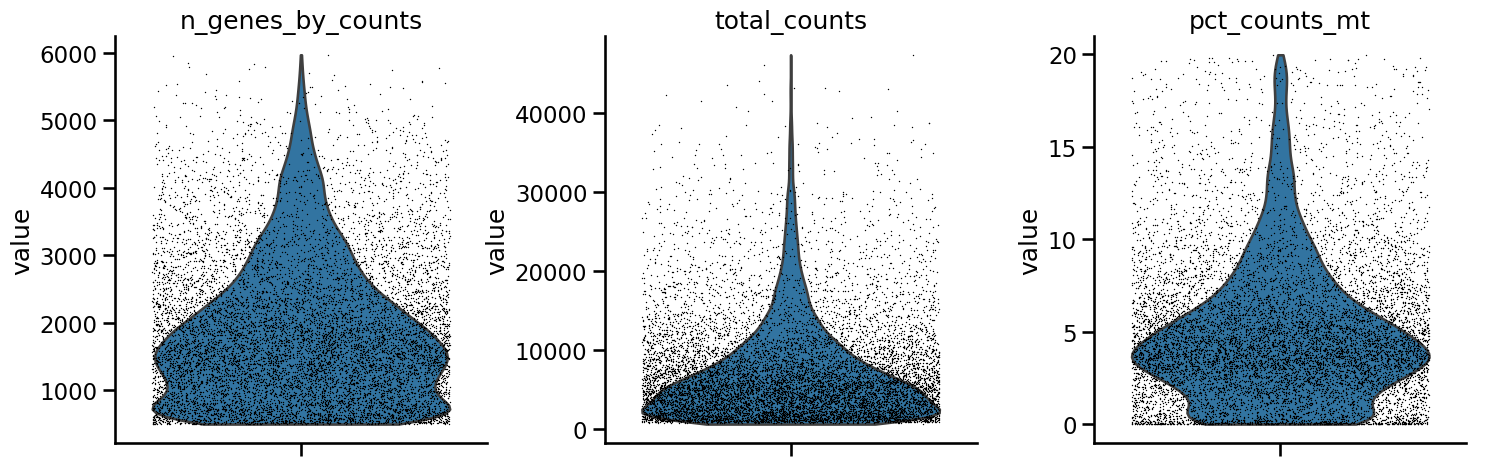

(10750, 25750)


In [81]:
import scanpy as sc
badata.layers["counts"] = badata.X.copy()
raw_var_names = badata.var_names.copy()

rawadata = badata.copy()

badata.var["mt"] = badata.var_names.str.startswith("MT-")
badata.var["ribo"] = badata.var_names.str.startswith(("RPS", "RPL"))
badata.var["hb"] = badata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    badata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
sc.pl.violin(
    badata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


print(badata.X.shape)

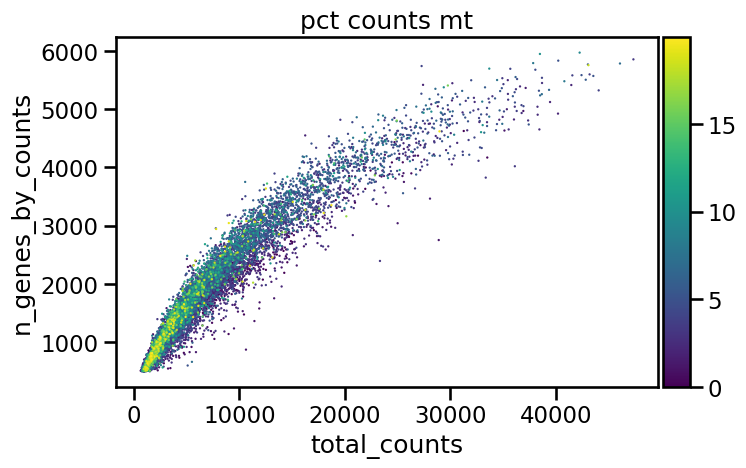

(10750, 19599)


In [82]:
sc.pl.scatter(badata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pp.filter_cells(badata, min_genes=100)
sc.pp.filter_genes(badata, min_cells=3)
print(badata.X.shape)

(10750, 19599)


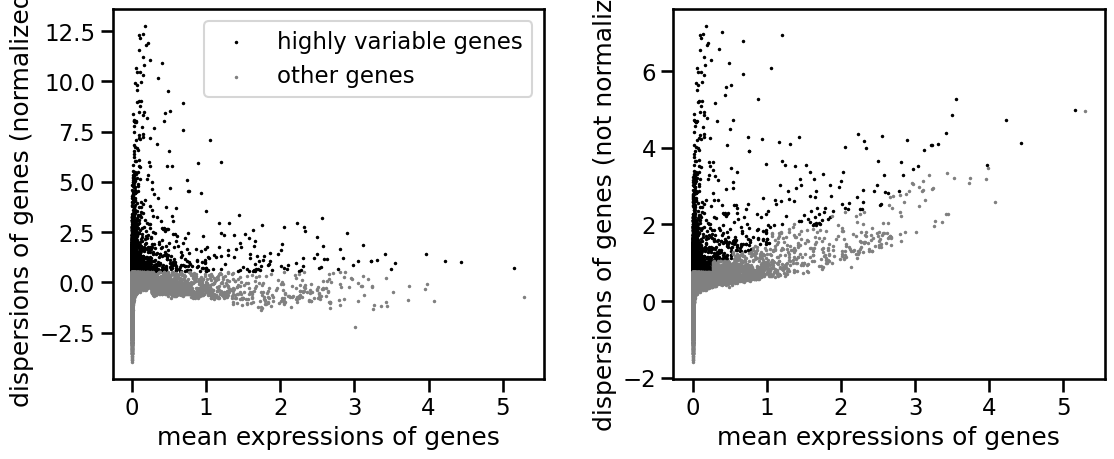

In [83]:
sc.pp.normalize_total(badata)
sc.pp.log1p(badata)
sc.pp.highly_variable_genes(badata, n_top_genes=3000)
print(badata.X.shape)

sc.pl.highly_variable_genes(badata)

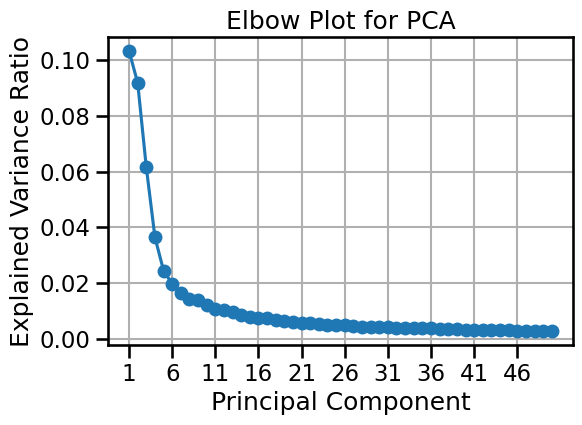

In [84]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(badata)
explained_variance_ratio = badata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

sc.tl.pca(badata, n_comps=26)

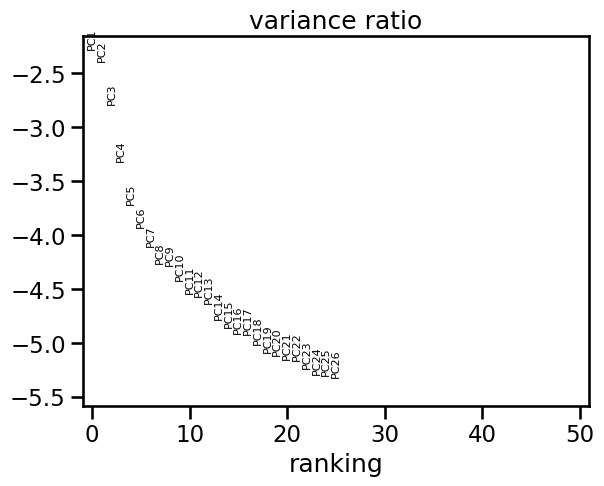

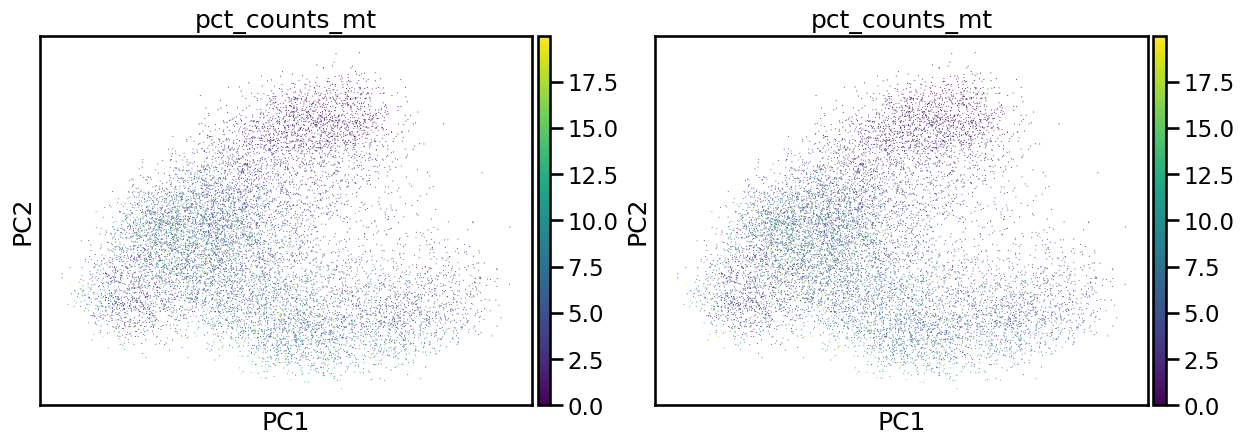

In [85]:
sc.pl.pca_variance_ratio(badata, n_pcs=50, log=True)
sc.pl.pca(
    badata,
    color=["pct_counts_mt", "pct_counts_mt"],
    ncols=2,
    size=2,
)

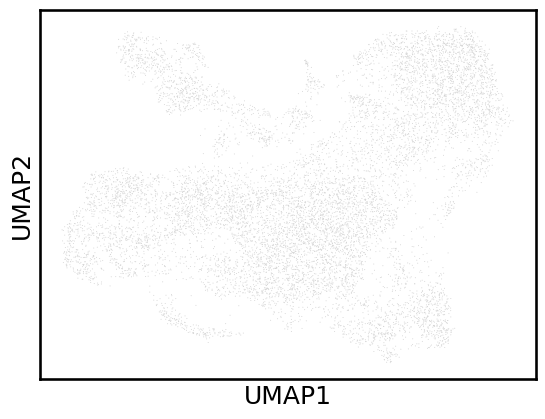

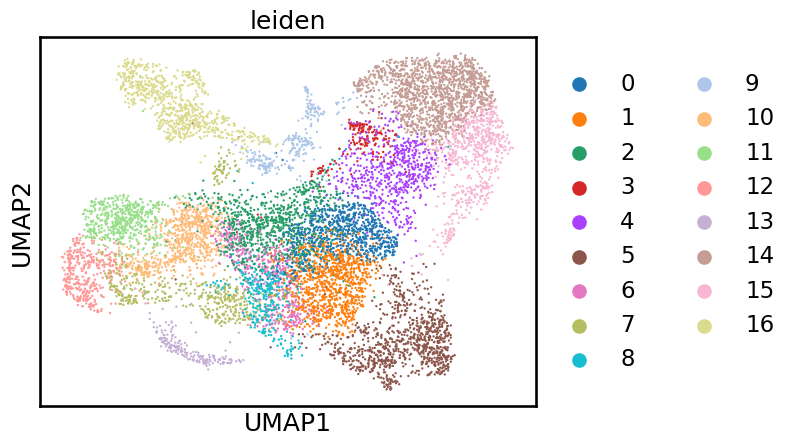

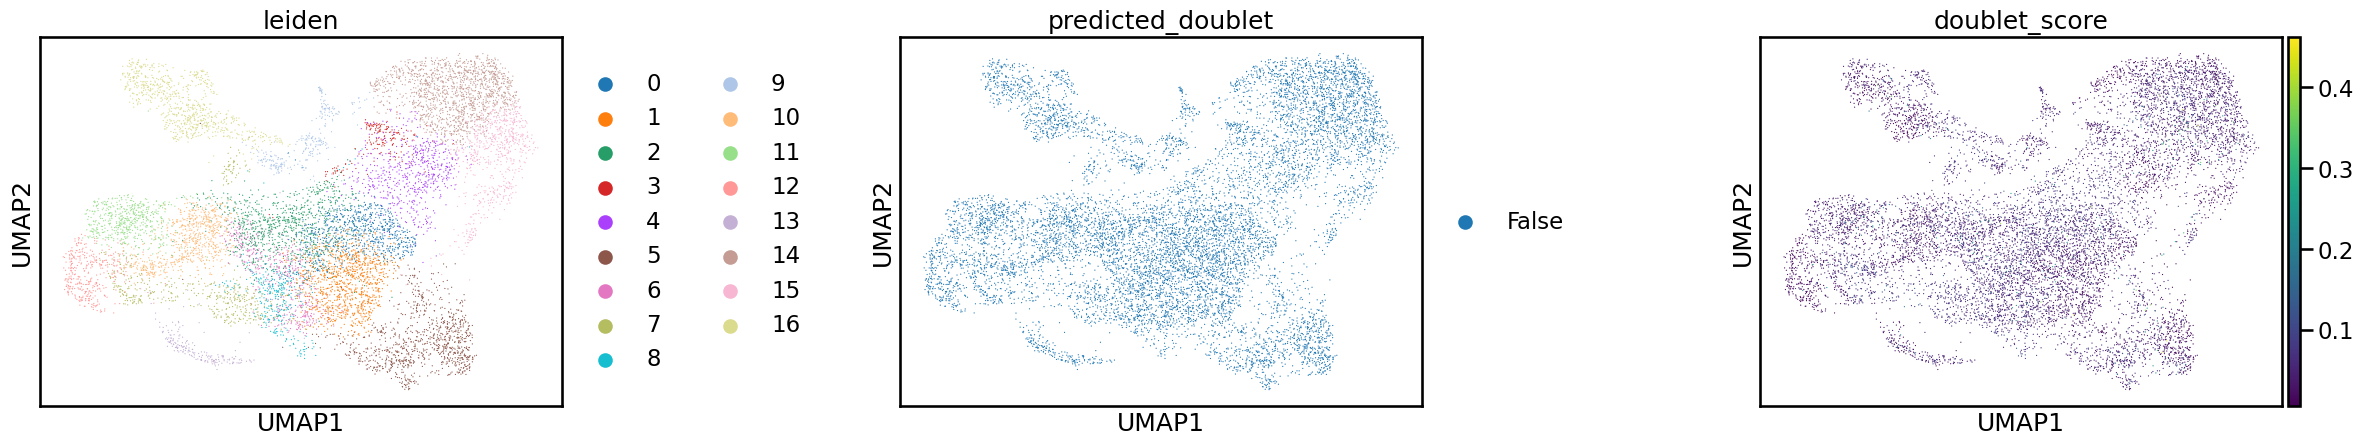

In [86]:
import bbknn 

# bbknn.bbknn(adata, batch_key='sample')
sc.pp.neighbors(badata)
sc.tl.leiden(badata, flavor="igraph", n_iterations=2)
sc.tl.umap(badata)
sc.pl.umap(
    badata,
    size=2,
)
sc.pl.umap(badata, color=["leiden"])
sc.pl.umap(
    badata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

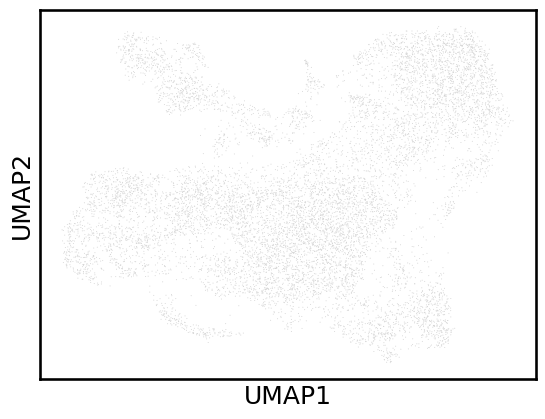

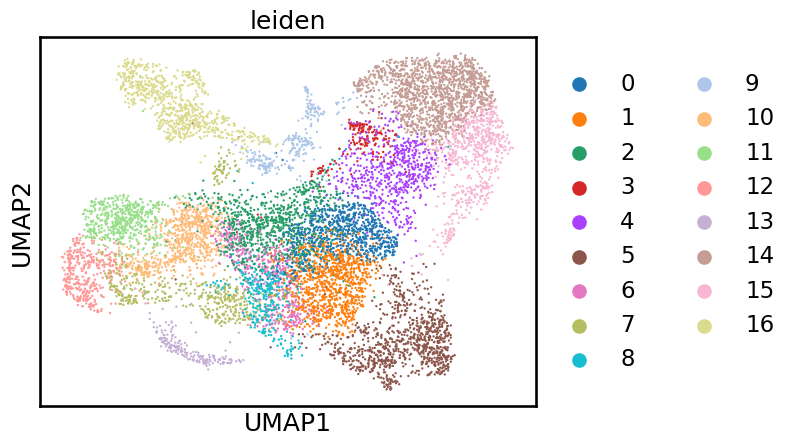

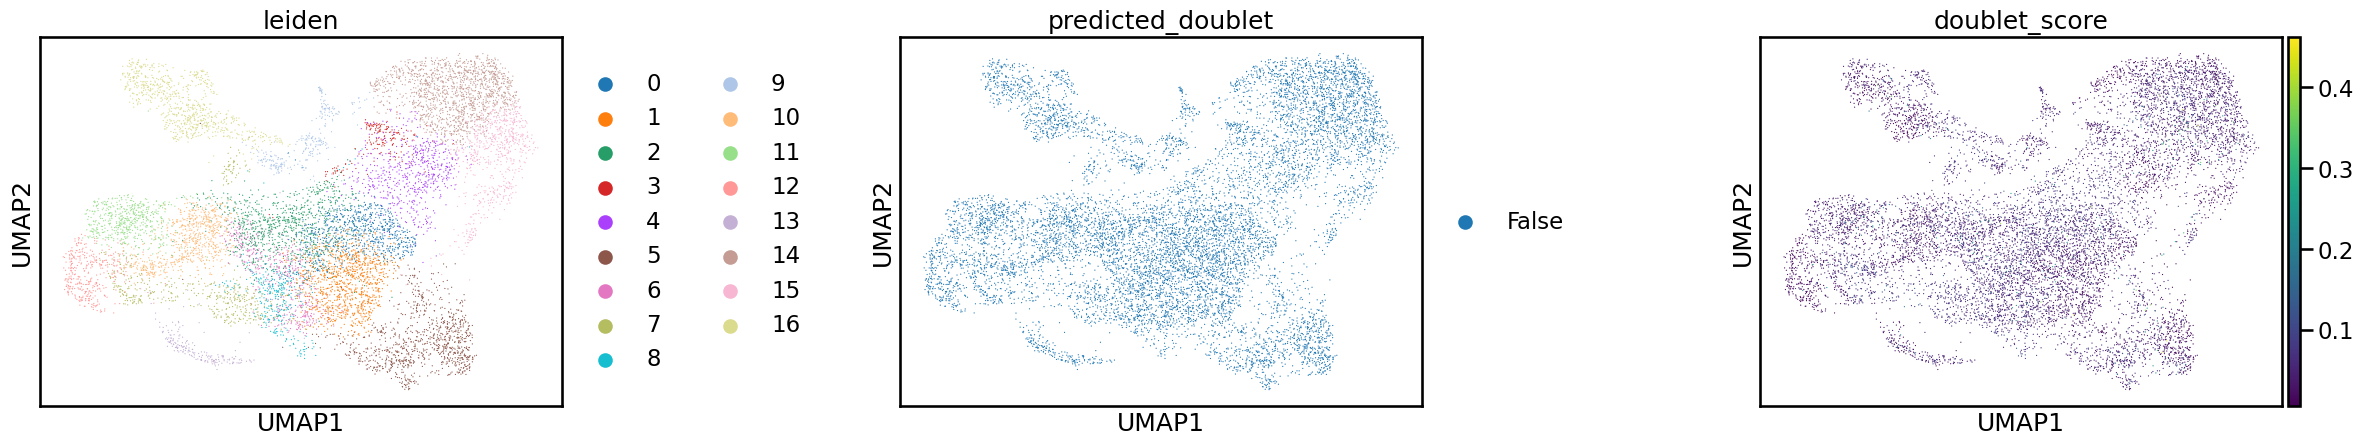

In [93]:
sce.pp.bbknn(badata, batch_key='predict')
sc.pp.neighbors(badata)
sc.tl.leiden(badata, flavor="igraph", n_iterations=2)
sc.tl.umap(badata)
sc.pl.umap(
    badata,
    size=2,
)
sc.pl.umap(badata, color=["leiden"])
sc.pl.umap(
    badata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

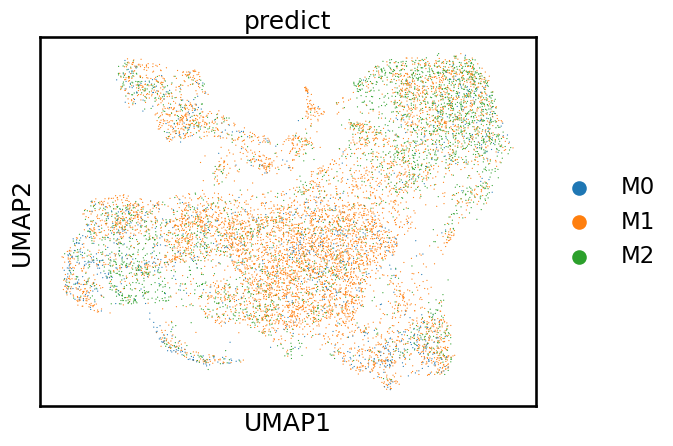

In [94]:
sc.pl.umap(
    badata,
    color=["predict"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

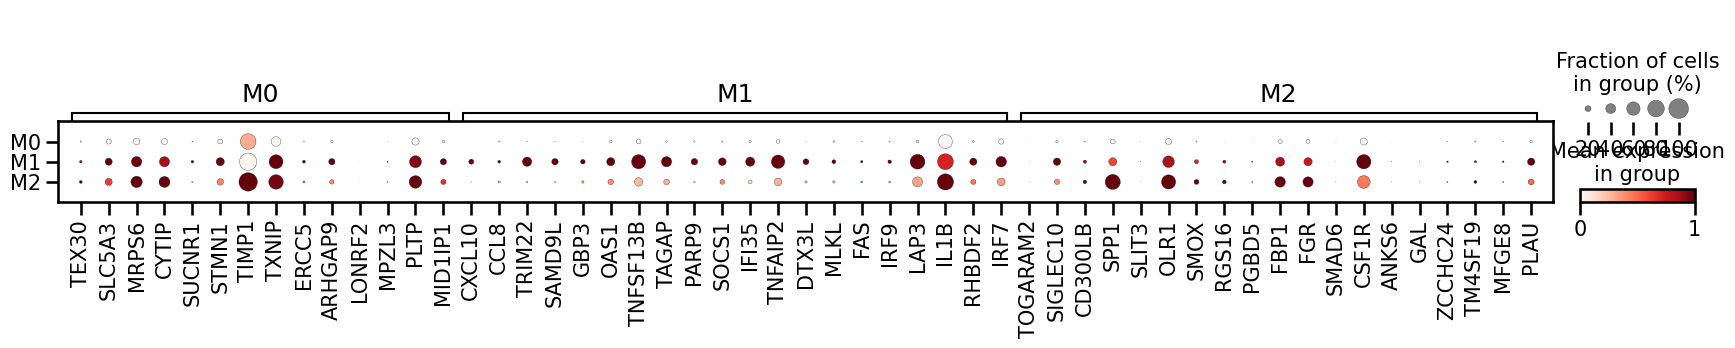

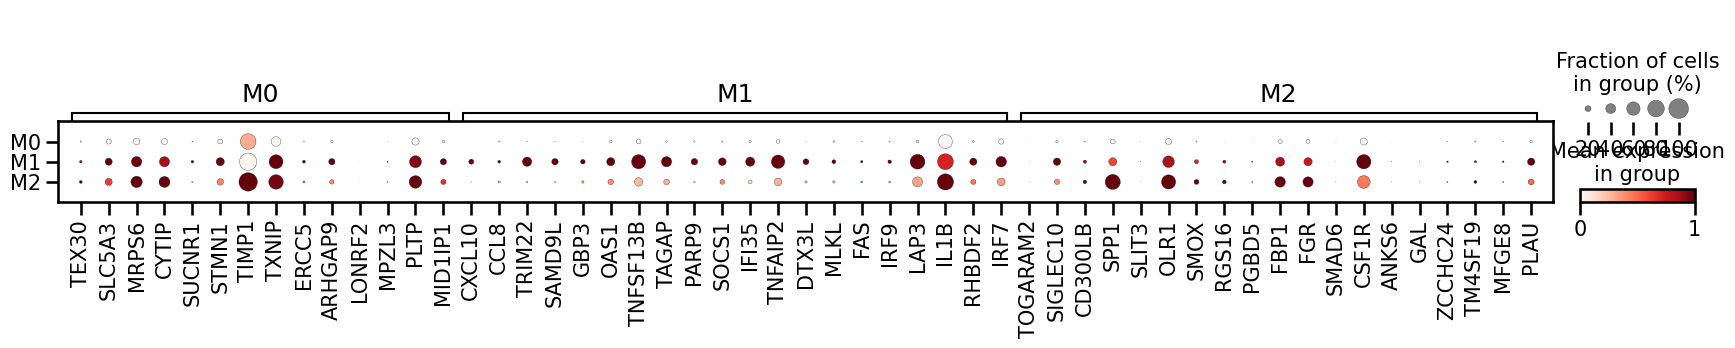

In [95]:
marker_genes = {cat: [gene for gene in genes if gene in badata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(badata, marker_genes, groupby="predict", standard_scale="var")
sc.pl.dotplot(badata, marker_genes, groupby="predict", standard_scale="var")

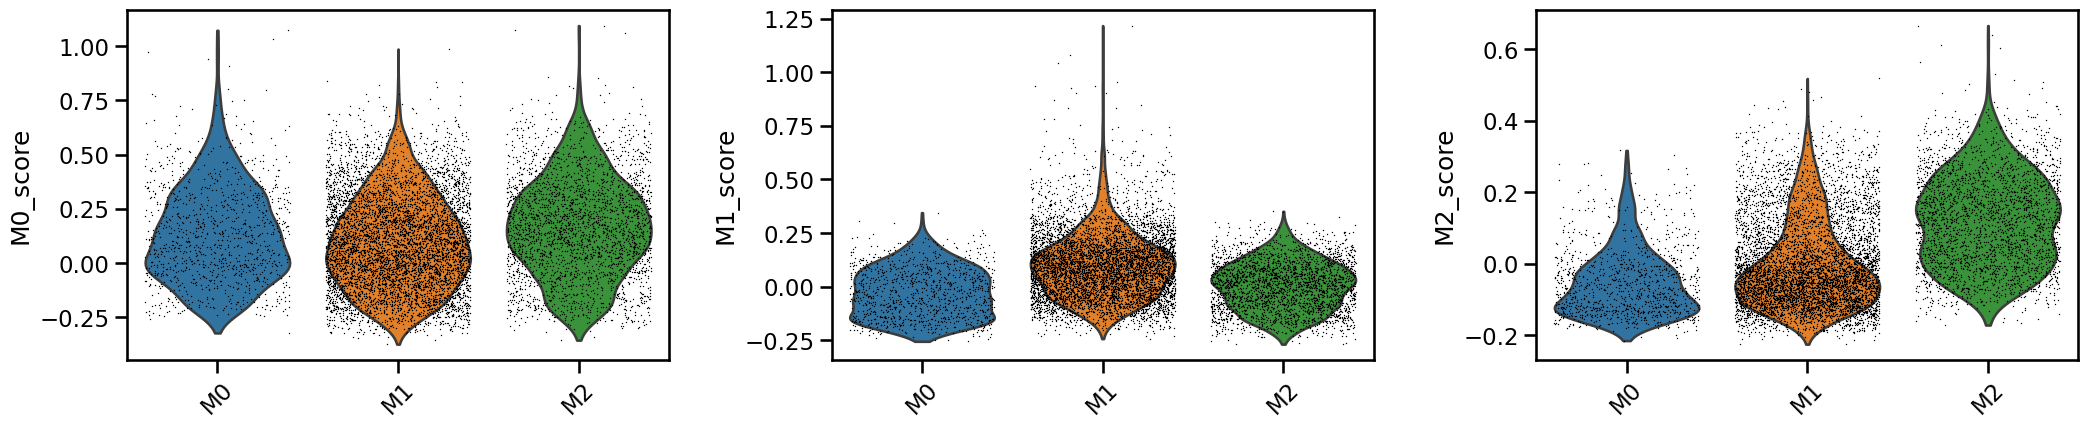

In [96]:
gene_sets = {
    "M0": ['TEX30', 'EGR1', 'SLC5A3', 'MRPS6', 'EGR3', 'FILIP1L', 'ADARB1', 'CYTIP', 'IL1RN', 'DUSP2', 'STMN1'],
    "M1": ['CXCL10', 'CCL8', 'TRIM22', 'SAMD9L', 'GBP3', 'OAS1', 'TNFSF13B', 'TAGAP', 'PARP9', 'SOCS1', 'IFI35', 'TNFAIP2', 'DTX3L', 'MLKL', 'FAS', 'IRF9', 'LAP3', 'IL1B', 'RHBDF2', 'IRF7'],
    "M2": ['TOGARAM2', 'SIGLEC10', 'CD300LB', 'SPP1', 'SLIT3', 'OLR1', 'SMOX', 'RGS16', 'PGBD5', 'FBP1', 'FGR', 'ATP2B2', 'SMAD6', 'CSF1R', 'ANKS6', 'GAL', 'ZCCHC24', 'TM4SF19', 'MFGE8', 'PLAU']
}

# 각 마커에 대해 score 계산
for label, genes in gene_sets.items():
    sc.tl.score_genes(badata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(badata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='predict', jitter=0.4, rotation=45)


In [97]:
# 'final' 컬럼 생성
badata.obs['final'] = badata.obs['predict'].copy()

# Categorical이면 'Unknown' 카테고리 추가
if pd.api.types.is_categorical_dtype(badata.obs['final']):
    badata.obs['final'] = badata.obs['final'].cat.add_categories(['Unknown'])

# max_prob < 0.6 인 경우 'Unknown'으로 지정
badata.obs.loc[badata.obs['max_prob'] < 0.0, 'final'] = 'Unknown'


/tmp/ipykernel_368257/1548546357.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(badata.obs['final']):


In [98]:
badata.obs['final'].value_counts()

final
M1         6755
M2         2898
M0         1097
Unknown       0
Name: count, dtype: int64

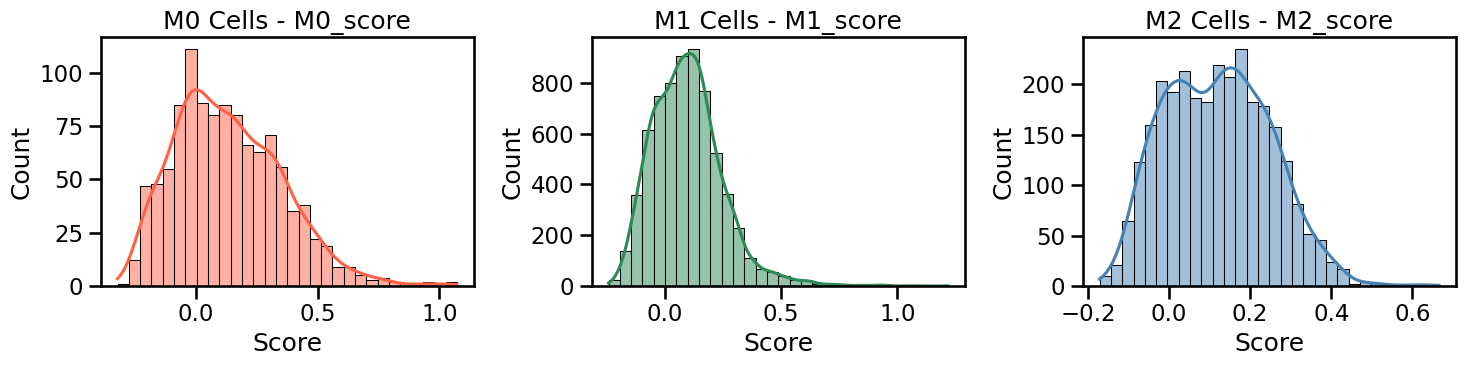

In [99]:
# 그룹별로 관련 score만 추출
df_M0 = badata.obs[badata.obs['final'] == 'M0'][['M0_score']]
df_M1 = badata.obs[badata.obs['final'] == 'M1'][['M1_score']]
df_M2 = badata.obs[badata.obs['final'] == 'M2'][['M2_score']]
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# M0
sns.histplot(df_M0['M0_score'], bins=30, kde=True, ax=axs[0], color='tomato')
axs[0].set_title('M0 Cells - M0_score')

# M1
sns.histplot(df_M1['M1_score'], bins=30, kde=True, ax=axs[1], color='seagreen')
axs[1].set_title('M1 Cells - M1_score')

# M2
sns.histplot(df_M2['M2_score'], bins=30, kde=True, ax=axs[2], color='steelblue')
axs[2].set_title('M2 Cells - M2_score')

for ax in axs:
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [100]:
# 1. final 값을 복사해서 final_celltype 생성
badata.obs['final_celltype'] = badata.obs['final'].copy()

# 2. Categorical이면 'Unknown'이 없을 때만 추가
if pd.api.types.is_categorical_dtype(badata.obs['final_celltype']):
    if 'Unknown' not in badata.obs['final_celltype'].cat.categories:
        badata.obs['final_celltype'] = badata.obs['final_celltype'].cat.add_categories(['Unknown'])

# 3. 조건별로 Unknown으로 변경
badata.obs.loc[(badata.obs['final'] == 'M0') & (badata.obs['M0_score'] < 0), 'final_celltype'] = 'Unknown'
badata.obs.loc[(badata.obs['final'] == 'M1') & (badata.obs['M1_score'] < 0), 'final_celltype'] = 'Unknown'
badata.obs.loc[(badata.obs['final'] == 'M2') & (badata.obs['M2_score'] < 0), 'final_celltype'] = 'Unknown'


/tmp/ipykernel_368257/1982667555.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(badata.obs['final_celltype']):


In [101]:
badata.obs['final_celltype'].value_counts()

final_celltype
M1         4891
Unknown    2811
M2         2300
M0          748
Name: count, dtype: int64

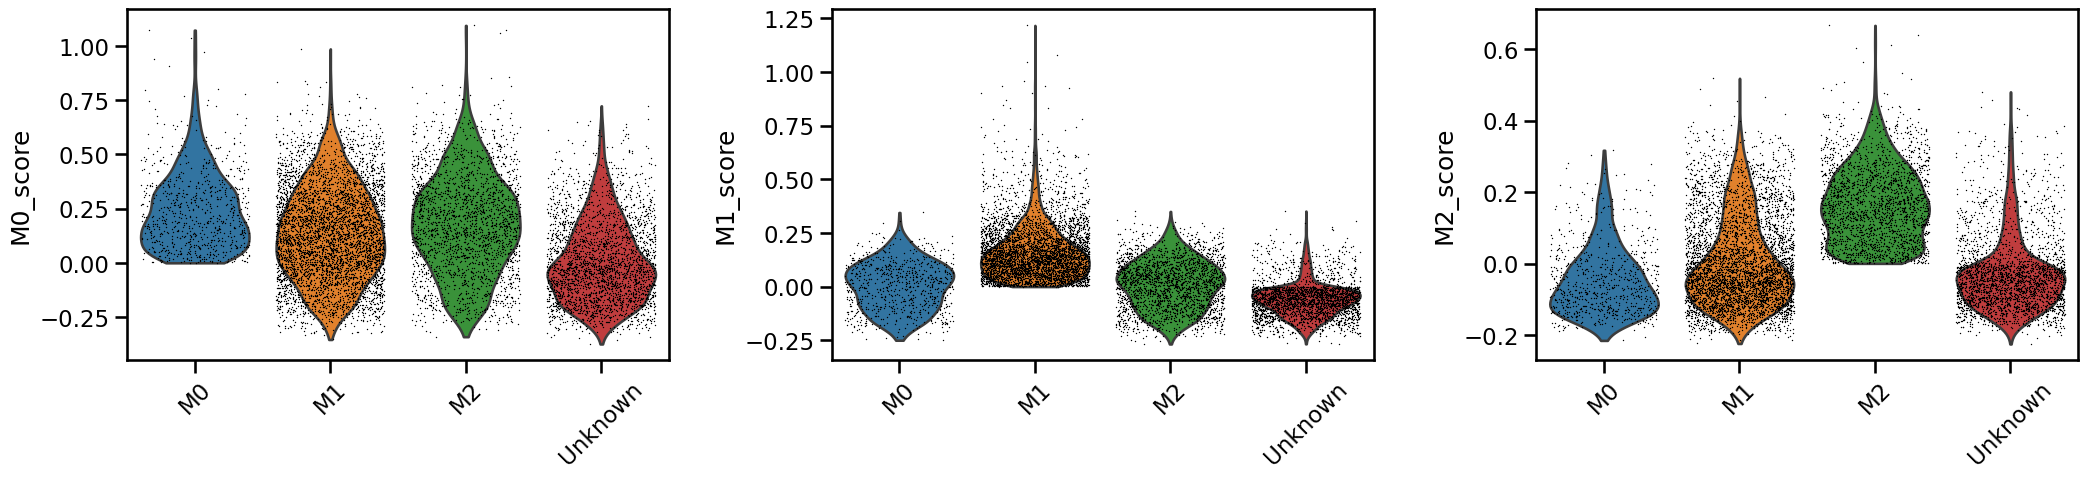

In [102]:
sc.pl.violin(badata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='final_celltype', jitter=0.4, rotation=45)


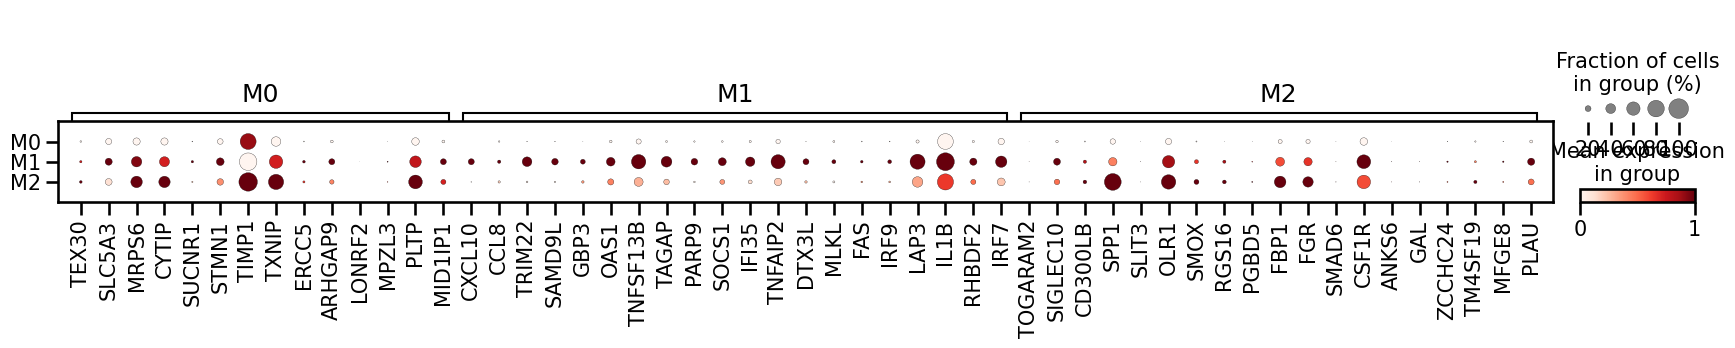

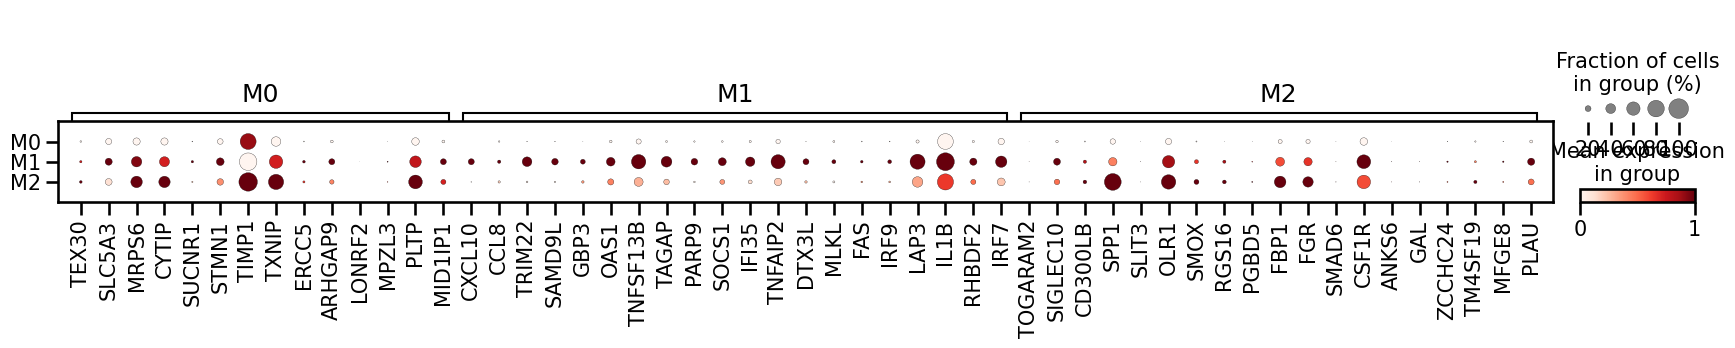

In [103]:
badata = badata[badata.obs['final_celltype'] != 'Unknown']
sc.pl.dotplot(badata, marker_genes, groupby="final_celltype", standard_scale="var")
sc.pl.dotplot(badata, marker_genes, groupby="final_celltype", standard_scale="var")

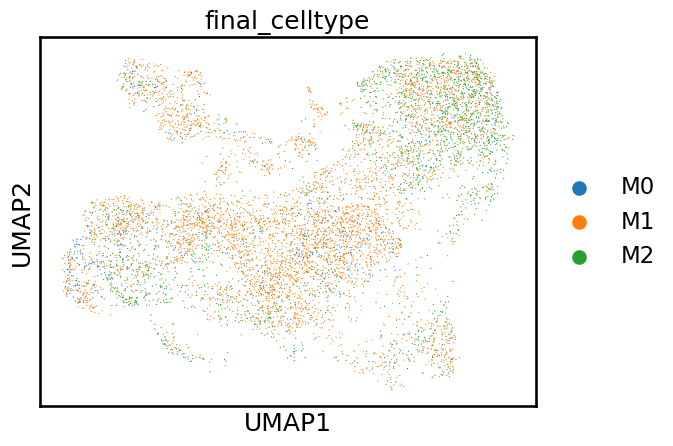

In [104]:
sc.pl.umap(
    badata,
    color=["final_celltype"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

In [91]:
all_genes = gene_sets["M0"] + gene_sets["M1"] + gene_sets["M2"]

# 없는 유전자 찾기
missing_genes = [gene for gene in all_genes if gene not in trainadata.var_names]

# 결과 출력
print(f"❗ trainadata에 없는 유전자 수: {len(missing_genes)}")
print("📛 없는 유전자 목록:")
print(missing_genes)

❗ trainadata에 없는 유전자 수: 8
📛 없는 유전자 목록:
['RPS27P29', 'RPSAP19', 'RPL7P32', 'TMSB4XP1', 'TMSB4XP8', 'GBP1P1', 'FCGR1CP', 'TOGARAM2']
